# 🏪 Store Sales — Time Series Forecasting
## Trend, Seasonality and Sales Prediction

**Author :** Handahamé DIA
**Date :** June 2026
**Tool :** Python (Pandas, Matplotlib, Prophet)
**Dataset :** Store Sales Time Series - Kaggle

---

## 📌 Objective
Analyze sales trends and seasonality patterns
across multiple store families to build a
reliable forecasting model that helps management
anticipate future performance and optimize
inventory and resources.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

print("Libraries imported successfully !")

Libraries imported successfully !


In [2]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
from google.colab import files
uploaded = files.upload()


Saving holidays_events.csv to holidays_events.csv
Saving stores.csv to stores.csv
Saving oil.csv to oil.csv


In [4]:
# Load all datasets
train = pd.read_csv('train.csv',
                    parse_dates=['date'])
stores = pd.read_csv('stores.csv')
oil = pd.read_csv('oil.csv',
                  parse_dates=['date'])
holidays = pd.read_csv('holidays_events.csv',
                       parse_dates=['date'])

# First look
print("TRAIN")
print(f"Shape : {train.shape}")
print(f"Period : {train['date'].min()} → {train['date'].max()}")
print(f"Columns : {train.columns.tolist()}")

print("\nSTORES")
print(f"Shape : {stores.shape}")
print(f"Columns : {stores.columns.tolist()}")

print("\nOIL")
print(f"Shape : {oil.shape}")

print("\nHOLIDAYS")
print(f"Shape : {holidays.shape}")

TRAIN
Shape : (3000888, 6)
Period : 2013-01-01 00:00:00 → 2017-08-15 00:00:00
Columns : ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

STORES
Shape : (54, 5)
Columns : ['store_nbr', 'city', 'state', 'type', 'cluster']

OIL
Shape : (1218, 2)

HOLIDAYS
Shape : (350, 6)


## 🔍 Data Exploration

In [5]:
# Train dataset details
print("TRAIN — First rows :")
print(train.head())

print("\nMissing values :")
print(train.isnull().sum())

print("\nProduct families :")
print(f"Number of families : {train['family'].nunique()}")
print(train['family'].unique())

print("\nStores :")
print(f"Number of stores : {train['store_nbr'].nunique()}")

TRAIN — First rows :
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0

Missing values :
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Product families :
Number of families : 33
['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE S

In [6]:
print("STORES :")
print(stores.head(10))

print("\nStore types :")
print(stores['type'].value_counts())

print("\nStore clusters :")
print(stores['cluster'].value_counts())

print("\nOIL — Missing values :")
print(oil.isnull().sum())
print(oil.head())

STORES :
   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4
5          6          Quito                       Pichincha    D       13
6          7          Quito                       Pichincha    D        8
7          8          Quito                       Pichincha    D        8
8          9          Quito                       Pichincha    B        6
9         10          Quito                       Pichincha    C       15

Store types :
type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64

Store clusters :
cluster
3     7
10    6
6     6
15    5
13    4
14    4
11    3
4     3
8

## 🧹 Data Cleaning and Preparation

In [7]:
# Interpolate missing oil prices
oil['dcoilwtico'] = oil['dcoilwtico'].interpolate(
    method='linear')

print("Oil missing values after interpolation :")
print(oil.isnull().sum())

# Aggregate total daily sales across all stores
daily_sales = train.groupby('date').agg(
    Total_Sales=('sales', 'sum'),
    Avg_Sales=('sales', 'mean'),
    Total_Promotions=('onpromotion', 'sum')
).reset_index()

# Add time features
daily_sales['Year'] = daily_sales['date'].dt.year
daily_sales['Month'] = daily_sales['date'].dt.month
daily_sales['DayOfWeek'] = daily_sales['date'].dt.dayofweek
daily_sales['Month_Name'] = daily_sales['date'].dt.strftime('%B')
daily_sales['Day_Name'] = daily_sales['date'].dt.strftime('%A')

print("\nDaily sales shape :", daily_sales.shape)
print(daily_sales.head())

Oil missing values after interpolation :
date          0
dcoilwtico    1
dtype: int64

Daily sales shape : (1684, 9)
        date    Total_Sales   Avg_Sales  Total_Promotions  Year  Month  \
0 2013-01-01    2511.618999    1.409438                 0  2013      1   
1 2013-01-02  496092.417944  278.390807                 0  2013      1   
2 2013-01-03  361461.231124  202.840197                 0  2013      1   
3 2013-01-04  354459.677093  198.911154                 0  2013      1   
4 2013-01-05  477350.121229  267.873244                 0  2013      1   

   DayOfWeek Month_Name   Day_Name  
0          1    January    Tuesday  
1          2    January  Wednesday  
2          3    January   Thursday  
3          4    January     Friday  
4          5    January   Saturday  


## 📊 Sales Overview

In [8]:
print("=" * 50)
print("GLOBAL SALES OVERVIEW")
print("=" * 50)
print(f"Period       : {daily_sales['date'].min().date()} → {daily_sales['date'].max().date()}")
print(f"Total days   : {len(daily_sales)}")
print(f"Total Sales  : ${daily_sales['Total_Sales'].sum():,.0f}")
print(f"Avg Daily    : ${daily_sales['Total_Sales'].mean():,.0f}")
print(f"Best day     : ${daily_sales['Total_Sales'].max():,.0f}")
print(f"Worst day    : ${daily_sales['Total_Sales'].min():,.0f}")
print("=" * 50)

GLOBAL SALES OVERVIEW
Period       : 2013-01-01 → 2017-08-15
Total days   : 1684
Total Sales  : $1,073,644,952
Avg Daily    : $637,556
Best day     : $1,463,084
Worst day    : $2,512


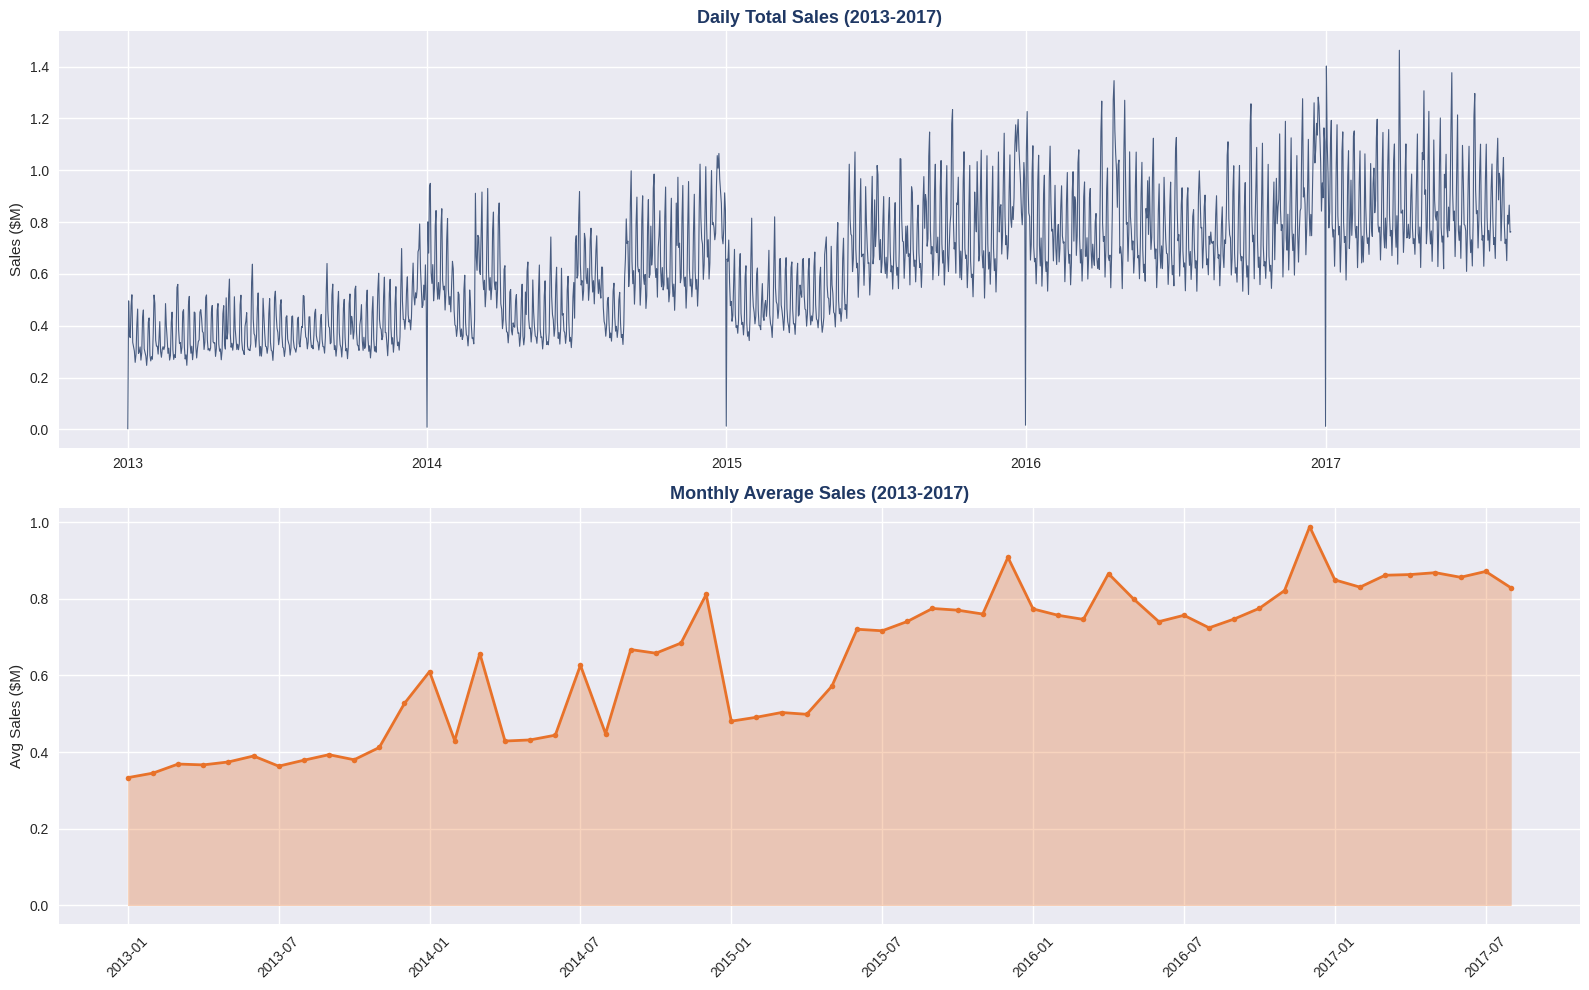

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Chart 1 - Daily Sales
axes[0].plot(daily_sales['date'],
             daily_sales['Total_Sales'] / 1e6,
             color='#1F3864', linewidth=0.8,
             alpha=0.8)
axes[0].set_title('Daily Total Sales (2013-2017)',
                   fontsize=13, fontweight='bold',
                   color='#1F3864')
axes[0].set_ylabel('Sales ($M)')
axes[0].set_xlabel('')

# Chart 2 - Monthly average
monthly = daily_sales.groupby(
    ['Year', 'Month'])['Total_Sales'].mean().reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + \
                    monthly['Month'].astype(str).str.zfill(2)

axes[1].plot(range(len(monthly)),
             monthly['Total_Sales'] / 1e6,
             color='#E8722A', linewidth=2,
             marker='o', markersize=4)
axes[1].fill_between(range(len(monthly)),
                     monthly['Total_Sales'] / 1e6,
                     alpha=0.3, color='#E8722A')
axes[1].set_title('Monthly Average Sales (2013-2017)',
                   fontsize=13, fontweight='bold',
                   color='#1F3864')
axes[1].set_ylabel('Avg Sales ($M)')
axes[1].set_xticks(range(0, len(monthly), 6))
axes[1].set_xticklabels(
    monthly['Period'].iloc[::6],
    rotation=45)

plt.tight_layout()
plt.savefig('sales_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 📅 Seasonality Analysis
### Sales by Year

In [11]:
yearly = daily_sales.groupby('Year').agg(
    Total_Sales=('Total_Sales', 'sum'),
    Avg_Daily=('Total_Sales', 'mean')
).reset_index()

yearly['Growth'] = yearly['Total_Sales'].pct_change() * 100

print("Sales by Year :")
print(yearly.to_string(index=False))

Sales by Year :
 Year  Total_Sales     Avg_Daily     Growth
 2013 1.404190e+08 385766.521757        NaN
 2014 2.094742e+08 575478.698631  49.177978
 2015 2.408801e+08 661758.518282  14.992704
 2016 2.886545e+08 790834.309463  19.833279
 2017 1.942171e+08 855581.799001 -32.716430


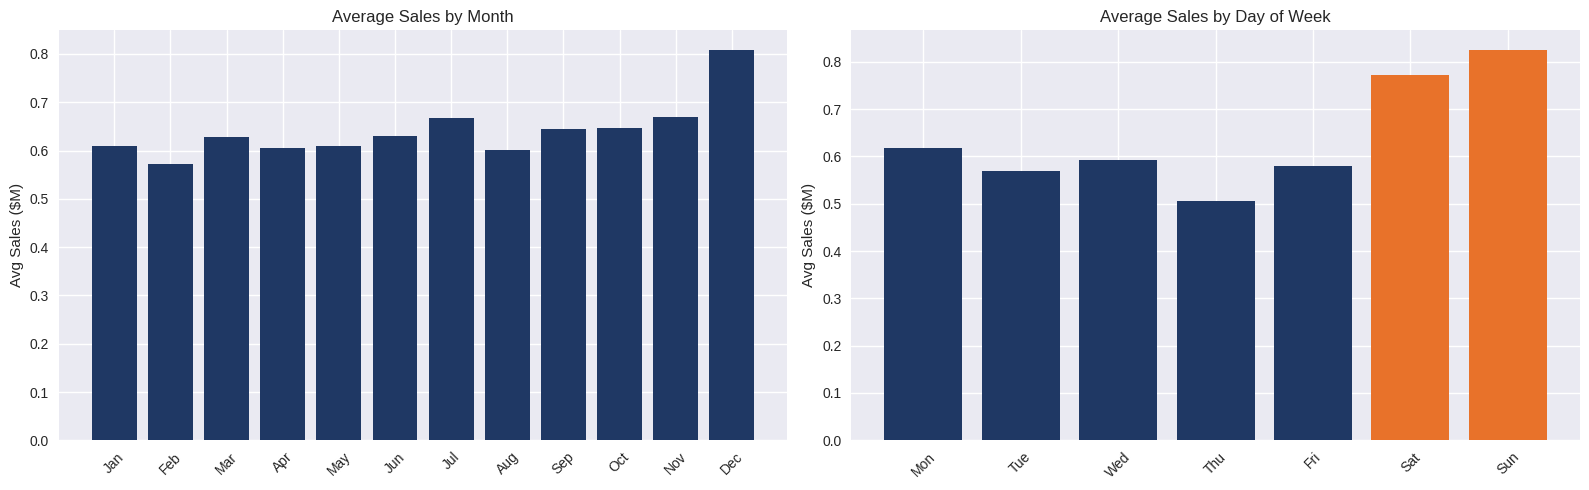

In [10]:
# Month order
month_order = ['January', 'February', 'March',
               'April', 'May', 'June', 'July',
               'August', 'September', 'October',
               'November', 'December']

monthly_avg = daily_sales.groupby(
    'Month_Name')['Total_Sales'].mean().reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1 - Monthly seasonality
axes[0].bar(range(len(monthly_avg)),
            monthly_avg / 1e6,
            color='#1F3864')
axes[0].set_title('Average Sales by Month')
axes[0].set_ylabel('Avg Sales ($M)')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(
    [m[:3] for m in month_order],
    rotation=45)

# Chart 2 - Day of week
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_avg = daily_sales.groupby(
    'Day_Name')['Total_Sales'].mean().reindex(day_order)

colors_days = ['#1F3864'] * 5 + ['#E8722A'] * 2
axes[1].bar(range(7), daily_avg / 1e6,
            color=colors_days)
axes[1].set_title('Average Sales by Day of Week')
axes[1].set_ylabel('Avg Sales ($M)')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(
    [d[:3] for d in day_order],
    rotation=45)

plt.tight_layout()
plt.savefig('seasonality.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Impact of Promotions on Sales

Correlation Promotions vs Sales :
                  Total_Sales  Total_Promotions
Total_Sales             1.000             0.575
Total_Promotions        0.575             1.000


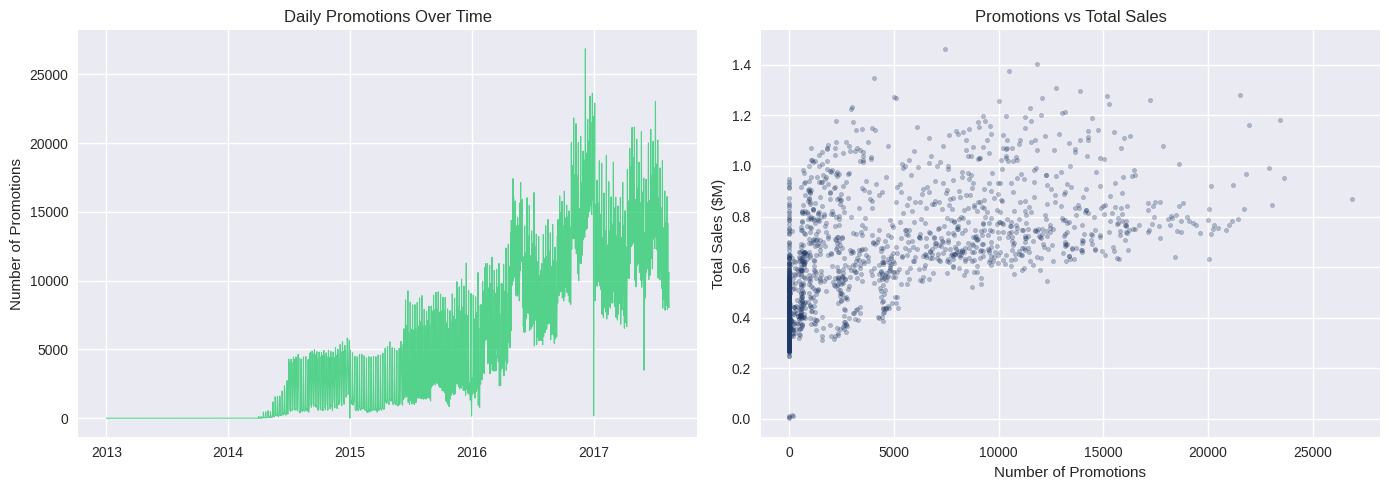

In [12]:
# Correlation promotions vs sales
corr = daily_sales[['Total_Sales',
                     'Total_Promotions']].corr()

print("Correlation Promotions vs Sales :")
print(corr.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Promotions over time
axes[0].plot(daily_sales['date'],
             daily_sales['Total_Promotions'],
             color='#2ECC71', linewidth=0.8,
             alpha=0.8)
axes[0].set_title('Daily Promotions Over Time')
axes[0].set_ylabel('Number of Promotions')

# Chart 2 - Scatter promotions vs sales
axes[1].scatter(daily_sales['Total_Promotions'],
                daily_sales['Total_Sales'] / 1e6,
                color='#1F3864', alpha=0.3, s=10)
axes[1].set_title('Promotions vs Total Sales')
axes[1].set_xlabel('Number of Promotions')
axes[1].set_ylabel('Total Sales ($M)')

plt.tight_layout()
plt.savefig('promotions_impact.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Top Product Families

Top 10 Product Families :
       family  Total_Sales   Avg_Sales
    GROCERY I 3.434627e+08 3776.972100
    BEVERAGES 2.169545e+08 2385.793151
      PRODUCE 1.227047e+08 1349.352123
     CLEANING 9.752129e+07 1072.416744
        DAIRY 6.448771e+07  709.154889
 BREAD/BAKERY 4.213395e+07  463.336254
      POULTRY 3.187600e+07  350.532292
        MEATS 3.108647e+07  341.849965
PERSONAL CARE 2.459205e+07  270.432513
         DELI 2.411032e+07  265.135067


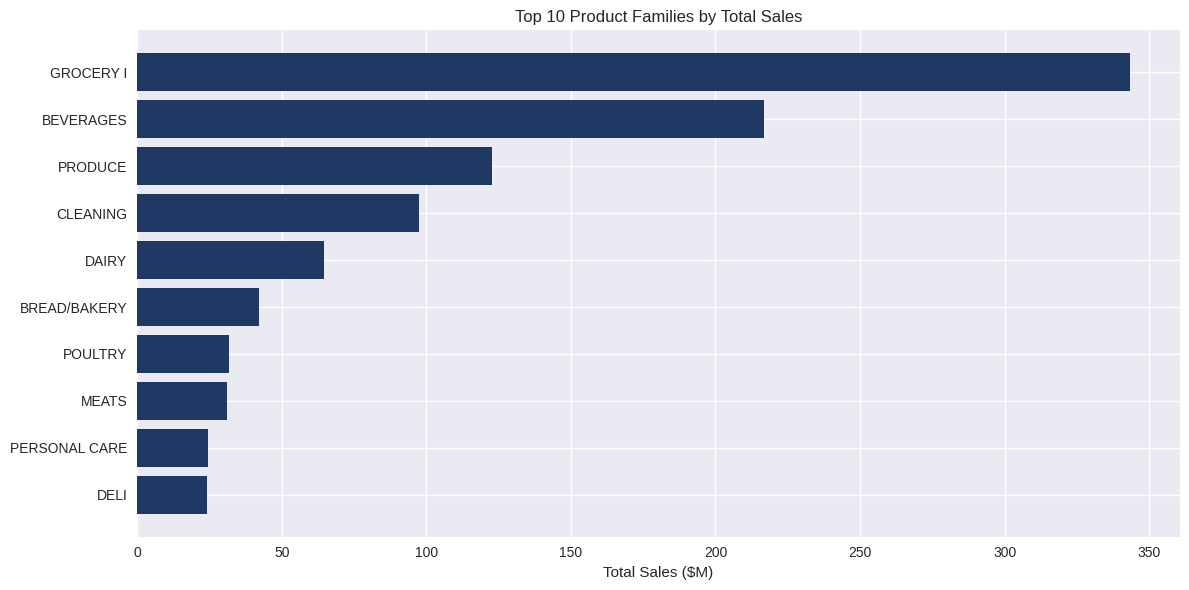

In [13]:
# Sales by product family
family_sales = train.groupby('family').agg(  Total_Sales=('sales', 'sum'),
    Avg_Sales=('sales', 'mean'),
    Total_Promotions=('onpromotion', 'sum')
).reset_index()

family_sales = family_sales.sort_values(
    'Total_Sales', ascending=False)

print("Top 10 Product Families :")
print(family_sales.head(10)[
    ['family', 'Total_Sales', 'Avg_Sales']
].to_string(index=False))

# Visualization Top 10
fig, ax = plt.subplots(figsize=(12, 6))

top10 = family_sales.head(10)
ax.barh(top10['family'],
        top10['Total_Sales'] / 1e6,
        color='#1F3864')
ax.set_title('Top 10 Product Families by Total Sales')
ax.set_xlabel('Total Sales ($M)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('family_sales.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Oil Price Impact on Sales

Correlation Oil Price vs Sales :
             Total_Sales  dcoilwtico
Total_Sales        1.000      -0.628
dcoilwtico        -0.628       1.000


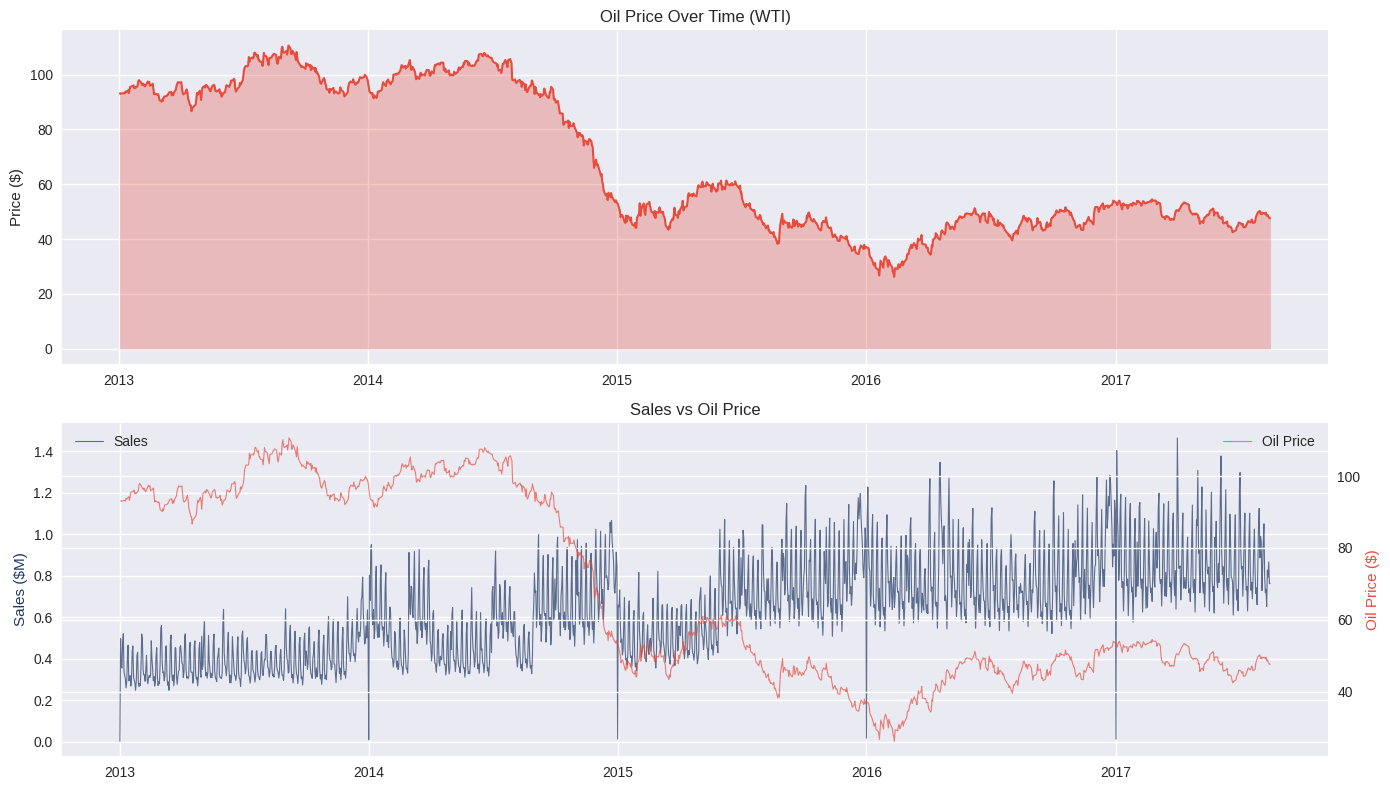

In [14]:
# Merge oil with daily sales
daily_oil = daily_sales.merge(oil,
                               on='date',
                               how='left')

# Fill remaining NaN
daily_oil['dcoilwtico'] = daily_oil[
    'dcoilwtico'].interpolate(method='linear')

# Correlation
corr_oil = daily_oil[['Total_Sales',
                       'dcoilwtico']].corr()
print("Correlation Oil Price vs Sales :")
print(corr_oil.round(3))

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Chart 1 - Oil price over time
axes[0].plot(daily_oil['date'],
             daily_oil['dcoilwtico'],
             color='#E74C3C', linewidth=1.5)
axes[0].set_title('Oil Price Over Time (WTI)')
axes[0].set_ylabel('Price ($)')
axes[0].fill_between(daily_oil['date'],
                     daily_oil['dcoilwtico'],
                     alpha=0.3, color='#E74C3C')

# Chart 2 - Sales vs Oil
ax2 = axes[1].twinx()
axes[1].plot(daily_oil['date'],
             daily_oil['Total_Sales'] / 1e6,
             color='#1F3864', linewidth=0.8,
             alpha=0.7, label='Sales')
ax2.plot(daily_oil['date'],
         daily_oil['dcoilwtico'],
         color='#E74C3C', linewidth=0.8,
         alpha=0.7, label='Oil Price')
axes[1].set_title('Sales vs Oil Price')
axes[1].set_ylabel('Sales ($M)', color='#1F3864')
ax2.set_ylabel('Oil Price ($)', color='#E74C3C')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('oil_impact.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Store Performance Analysis

In [33]:
# Merge train with stores info
train_stores = train.merge(stores,
                            on='store_nbr',
                            how='left')

# Sales by store type
store_type = train_stores.groupby('type').agg(
    Total_Sales=('sales', 'sum'),
    Avg_Sales=('sales', 'mean'),
    Store_Count=('store_nbr', 'nunique')
).reset_index()

store_type['Sales_per_Store'] = (
    store_type['Total_Sales'] /
    store_type['Store_Count']
)

store_type = store_type.sort_values(
    'Sales_per_Store', ascending=False)

print("Sales by Store Type :")
print(store_type.to_string(index=False))

Sales by Store Type :
type  Total_Sales  Avg_Sales  Store_Count  Sales_per_Store
   A 3.530438e+08 705.878743            9     3.922709e+07
   D 3.510833e+08 350.979407           18     1.950463e+07
   B 1.452606e+08 326.739714            8     1.815758e+07
   E 5.982244e+07 269.121301            4     1.495561e+07
   C 1.644347e+08 197.263301           15     1.096232e+07


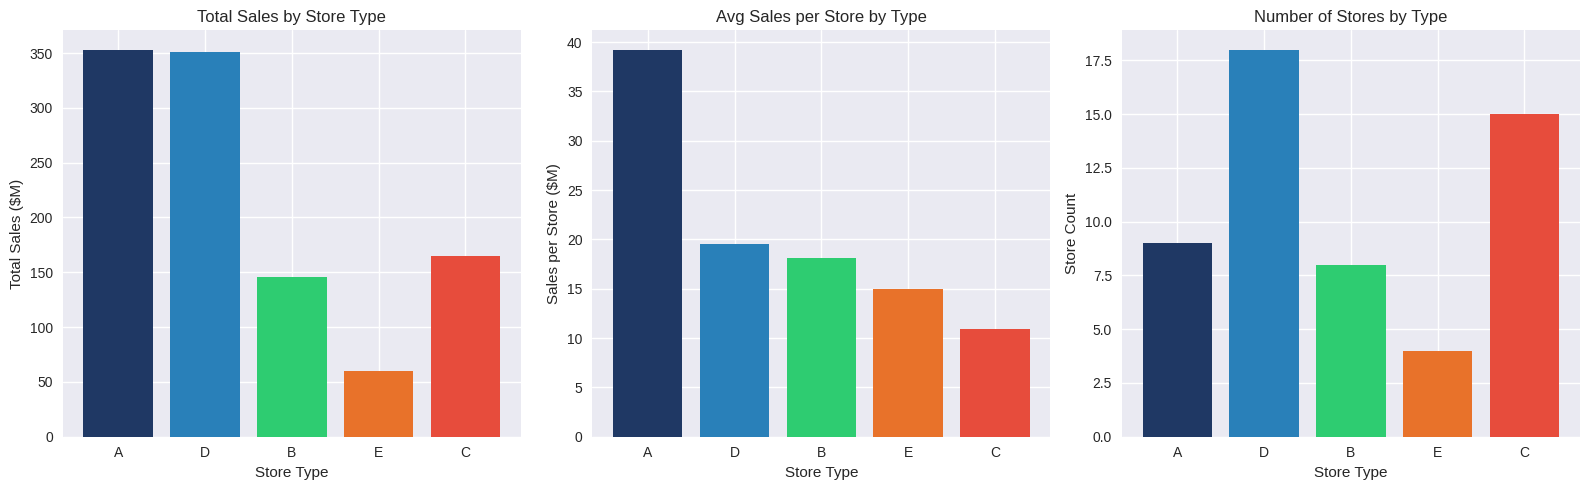

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#1F3864', '#2980B9', '#2ECC71',
          '#E8722A', '#E74C3C']

# Chart 1 - Total Sales by type
axes[0].bar(store_type['type'],
            store_type['Total_Sales'] / 1e6,
            color=colors)
axes[0].set_title('Total Sales by Store Type')
axes[0].set_ylabel('Total Sales ($M)')
axes[0].set_xlabel('Store Type')

# Chart 2 - Sales per store
axes[1].bar(store_type['type'],
            store_type['Sales_per_Store'] / 1e6,
            color=colors)
axes[1].set_title('Avg Sales per Store by Type')
axes[1].set_ylabel('Sales per Store ($M)')
axes[1].set_xlabel('Store Type')

# Chart 3 - Store count
axes[2].bar(store_type['type'],
            store_type['Store_Count'],
            color=colors)
axes[2].set_title('Number of Stores by Type')
axes[2].set_ylabel('Store Count')
axes[2].set_xlabel('Store Type')

plt.tight_layout()
plt.savefig('store_type_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

Top 10 Stores :
 store_nbr      city type  Total_Sales
        44     Quito    A 6.208755e+07
        45     Quito    A 5.449801e+07
        47     Quito    A 5.094831e+07
         3     Quito    D 5.048191e+07
        49     Quito    A 4.342010e+07
        46     Quito    A 4.189606e+07
        48     Quito    A 3.593313e+07
        51 Guayaquil    A 3.291149e+07
         8     Quito    D 3.049429e+07
        50    Ambato    A 2.865302e+07

Bottom 10 Stores :
 store_nbr          city type  Total_Sales
        29     Guayaquil    E 9.725158e+06
        10         Quito    C 9.613906e+06
        21 Santo Domingo    B 9.255506e+06
        42        Cuenca    D 8.945768e+06
        26     Guayaquil    D 7.755122e+06
        35        Playas    C 7.676679e+06
        30     Guayaquil    C 7.382074e+06
        32     Guayaquil    C 5.951796e+06
        22          Puyo    C 4.090202e+06
        52         Manta    A 2.696170e+06


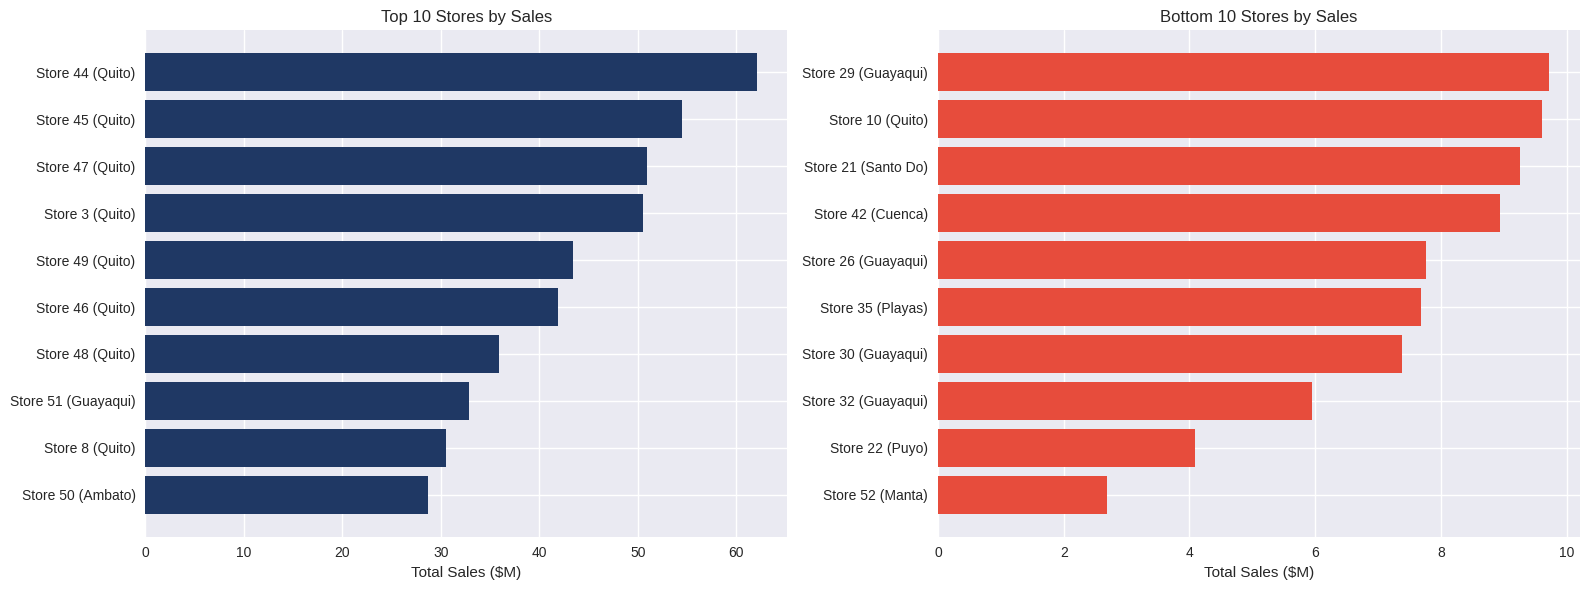

In [35]:
# Sales by individual store
store_perf = train_stores.groupby(
    ['store_nbr', 'city', 'type']).agg(
    Total_Sales=('sales', 'sum')
).reset_index().sort_values(
    'Total_Sales', ascending=False)

print("Top 10 Stores :")
print(store_perf.head(10).to_string(index=False))

print("\nBottom 10 Stores :")
print(store_perf.tail(10).to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10
top10 = store_perf.head(10)
axes[0].barh(
    [f"Store {r['store_nbr']} ({r['city'][:8]})"
     for _, r in top10.iterrows()],
    top10['Total_Sales'] / 1e6,
    color='#1F3864')
axes[0].set_title('Top 10 Stores by Sales')
axes[0].set_xlabel('Total Sales ($M)')
axes[0].invert_yaxis()

# Bottom 10
bottom10 = store_perf.tail(10)
axes[1].barh(
    [f"Store {r['store_nbr']} ({r['city'][:8]})"
     for _, r in bottom10.iterrows()],
    bottom10['Total_Sales'] / 1e6,
    color='#E74C3C')
axes[1].set_title('Bottom 10 Stores by Sales')
axes[1].set_xlabel('Total Sales ($M)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('store_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Top 5 Families Evolution Over Time

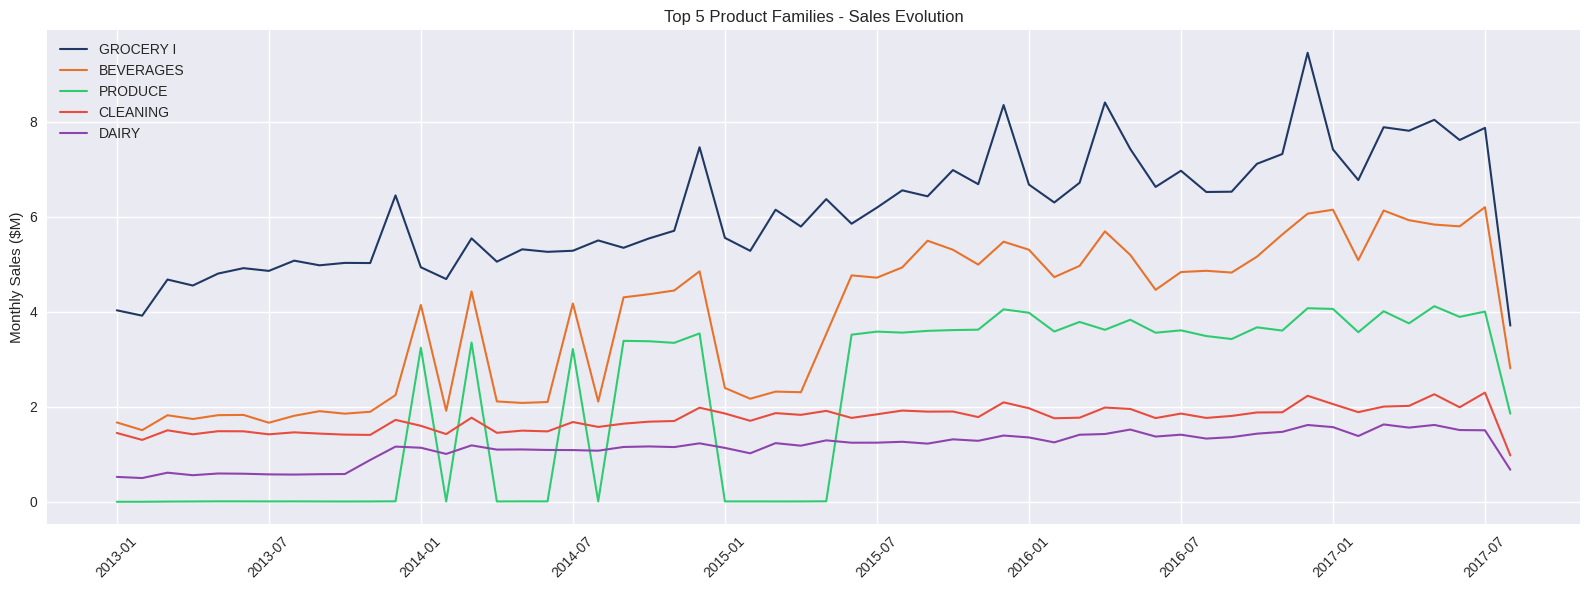

In [37]:
# Top 5 families
top5_families = ['GROCERY I', 'BEVERAGES',
                 'PRODUCE', 'CLEANING', 'DAIRY']

# Monthly sales for top 5
family_time = train[
    train['family'].isin(top5_families)
].copy()

family_time['Year'] = family_time['date'].dt.year
family_time['Month'] = family_time['date'].dt.month

family_monthly = family_time.groupby(
    ['Year', 'Month', 'family'])['sales'].sum(
).reset_index()

family_monthly['Period'] = (
    family_monthly['Year'].astype(str) + '-' +
    family_monthly['Month'].astype(str).str.zfill(2)
)

# Plot
plt.figure(figsize=(16, 6))

colors_families = ['#1F3864', '#E8722A',
                   '#2ECC71', '#E74C3C', '#8E44AD']

for i, family in enumerate(top5_families):
    data = family_monthly[
        family_monthly['family'] == family]
    plt.plot(range(len(data)),
             data['sales'] / 1e6,
             label=family,
             color=colors_families[i],
             linewidth=1.5)

plt.title('Top 5 Product Families - Sales Evolution')
plt.ylabel('Monthly Sales ($M)')
plt.xlabel('')

# X axis labels
periods = family_monthly[
    family_monthly['family'] == 'GROCERY I'][
    'Period'].tolist()
plt.xticks(range(0, len(periods), 6),
           periods[::6], rotation=45)

plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('family_evolution.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Holiday Impact on Sales

National holidays : 60
         date                    description
14 2012-08-10  Primer Grito de Independencia
19 2012-10-09     Independencia de Guayaquil
21 2012-11-02                Dia de Difuntos
22 2012-11-03        Independencia de Cuenca
37 2012-12-25                        Navidad
41 2013-01-01             Primer dia del ano
44 2013-02-11                       Carnaval
45 2013-02-12                       Carnaval
51 2013-04-29                  Viernes Santo
52 2013-05-01                Dia del Trabajo

Sales comparison :
                mean    median  count
Normal Day  638691.0  632489.0   1637
Holiday     598031.0  613973.0     47


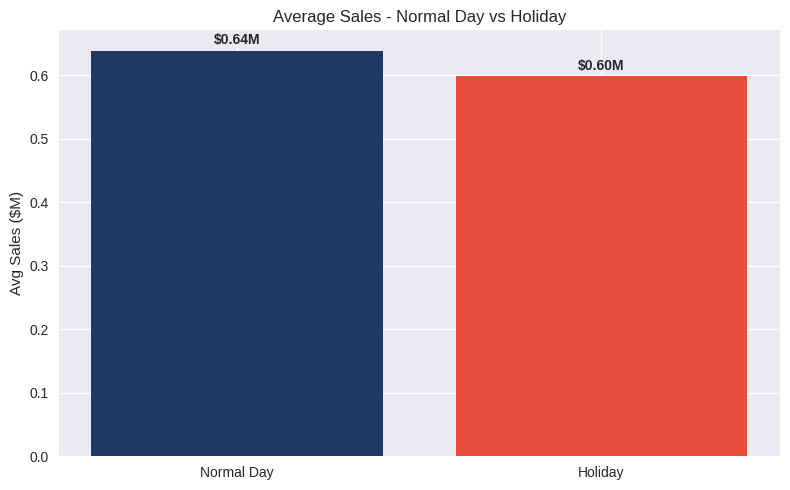

In [16]:
# Filter national holidays only
national_holidays = holidays[
    (holidays['locale'] == 'National') &
    (holidays['type'] == 'Holiday')
].copy()

print(f"National holidays : {len(national_holidays)}")
print(national_holidays[['date', 'description']].head(10))

# Merge with daily sales
daily_holidays = daily_sales.merge(
    national_holidays[['date']].assign(is_holiday=1),
    on='date', how='left')
daily_holidays['is_holiday'] = daily_holidays[
    'is_holiday'].fillna(0)

# Compare sales on holidays vs normal days
holiday_impact = daily_holidays.groupby(
    'is_holiday')['Total_Sales'].agg(
    ['mean', 'median', 'count']).round(0)

holiday_impact.index = ['Normal Day', 'Holiday']
print("\nSales comparison :")
print(holiday_impact.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))

means = holiday_impact['mean']
ax.bar(['Normal Day', 'Holiday'],
       means / 1e6,
       color=['#1F3864', '#E74C3C'])
ax.set_title('Average Sales - Normal Day vs Holiday')
ax.set_ylabel('Avg Sales ($M)')

for i, v in enumerate(means / 1e6):
    ax.text(i, v + 0.01, f'${v:.2f}M',
            ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('holiday_impact.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Heatmap - Sales by Day and Month

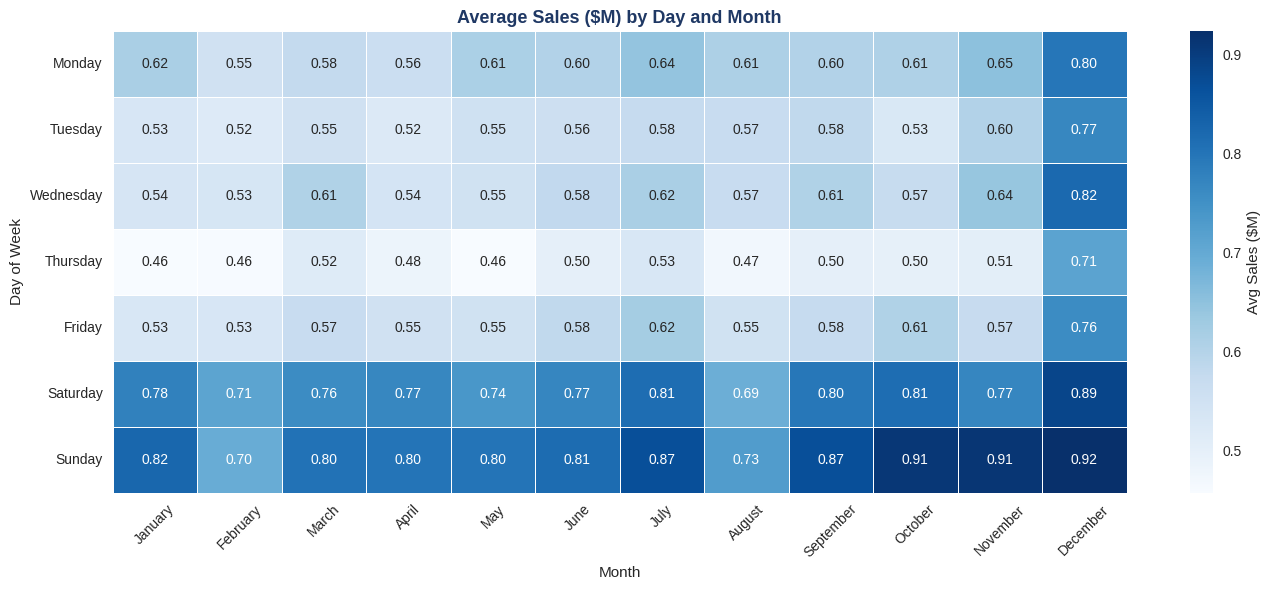

In [32]:
# Pivot table Day x Month
heatmap_data = daily_sales.pivot_table(
    values='Total_Sales',
    index='Day_Name',
    columns='Month_Name',
    aggfunc='mean'
)

# Reorder days and months
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday',
             'Saturday', 'Sunday']

month_order = ['January', 'February', 'March',
               'April', 'May', 'June',
               'July', 'August', 'September',
               'October', 'November', 'December']

heatmap_data = heatmap_data.reindex(
    index=day_order,
    columns=month_order)

# Plot
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data / 1e6,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            linewidths=0.5,
            cbar_kws={'label': 'Avg Sales ($M)'})

plt.title('Average Sales ($M) by Day and Month',
           fontsize=13, fontweight='bold',
           color='#1F3864')
plt.xlabel('Month')
plt.ylabel('Day of Week')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('heatmap_seasonality.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 🔮 Sales Forecasting with Prophet
### Step 1 - Installing and Preparing Prophet

In [17]:
# Install Prophet
!pip install prophet -q

from prophet import Prophet

# Prepare data for Prophet
# Prophet requires columns 'ds' and 'y'
prophet_data = daily_sales[['date', 'Total_Sales']].copy()
prophet_data.columns = ['ds', 'y']

print("Prophet data ready :")
print(prophet_data.shape)
print(prophet_data.head())
print(f"\nDate range : {prophet_data['ds'].min().date()}")
print(f"           → {prophet_data['ds'].max().date()}")

Prophet data ready :
(1684, 2)
          ds              y
0 2013-01-01    2511.618999
1 2013-01-02  496092.417944
2 2013-01-03  361461.231124
3 2013-01-04  354459.677093
4 2013-01-05  477350.121229

Date range : 2013-01-01
           → 2017-08-15


### Step 2 - Training the Prophet Model

In [18]:
# Initialize and train Prophet
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

# Add holidays
model.add_country_holidays(country_name='EC')

# Train
model.fit(prophet_data)
print("Model trained successfully !")

Model trained successfully !


### Step 2b - Improved Prophet with External Regressors

In [28]:
# Prepare data with regressors
prophet_data_v2 = daily_sales[
    ['date', 'Total_Sales',
     'Total_Promotions']].copy()
prophet_data_v2.columns = ['ds', 'y', 'promotions']

# Add oil prices
prophet_data_v2 = prophet_data_v2.merge(
    oil.rename(columns={
        'date': 'ds',
        'dcoilwtico': 'oil_price'}),
    on='ds', how='left')

# Interpolate missing oil
prophet_data_v2['oil_price'] = prophet_data_v2[
    'oil_price'].interpolate(method='linear')

# Fill first NaN if any
prophet_data_v2['oil_price'] = prophet_data_v2[
    'oil_price'].fillna(method='bfill')

print("Data with regressors ready :")
print(prophet_data_v2.head())
print(f"\nMissing values :")
print(prophet_data_v2.isnull().sum())

Data with regressors ready :
          ds              y  promotions  oil_price
0 2013-01-01    2511.618999           0  93.140000
1 2013-01-02  496092.417944           0  93.140000
2 2013-01-03  361461.231124           0  92.970000
3 2013-01-04  354459.677093           0  93.120000
4 2013-01-05  477350.121229           0  93.146667

Missing values :
ds            0
y             0
promotions    0
oil_price     0
dtype: int64


In [29]:
# Initialize improved Prophet
model_v2 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)

# Add country holidays
model_v2.add_country_holidays(country_name='EC')

# Add external regressors
model_v2.add_regressor('promotions')
model_v2.add_regressor('oil_price')

# Train
model_v2.fit(prophet_data_v2)
print("Improved model trained successfully !")

Improved model trained successfully !


### Step 3 - Forecasting Next 90 Days

In [19]:
# Create future dataframe
future = model.make_future_dataframe(periods=90)

# Generate forecast
forecast = model.predict(future)

print("Forecast generated !")
print(f"Total rows : {len(forecast)}")
print("\nForecast columns :")
print(forecast[['ds', 'yhat',
                'yhat_lower',
                'yhat_upper']].tail(10))

Forecast generated !
Total rows : 1774

Forecast columns :
             ds          yhat    yhat_lower    yhat_upper
1764 2017-11-04  1.076982e+06  9.569775e+05  1.195126e+06
1765 2017-11-05  1.167283e+06  1.045149e+06  1.287051e+06
1766 2017-11-06  8.604405e+05  7.384851e+05  9.759195e+05
1767 2017-11-07  8.091603e+05  6.920836e+05  9.257512e+05
1768 2017-11-08  8.532131e+05  7.382453e+05  9.677599e+05
1769 2017-11-09  7.257757e+05  6.127922e+05  8.422743e+05
1770 2017-11-10  8.464473e+05  7.187067e+05  9.685683e+05
1771 2017-11-11  1.114915e+06  9.982898e+05  1.234008e+06
1772 2017-11-12  1.203479e+06  1.085965e+06  1.315251e+06
1773 2017-11-13  8.932437e+05  7.803243e+05  1.005450e+06


In [31]:
# Future dataframe with regressors
future_v2 = model_v2.make_future_dataframe(
    periods=90)

# Fill regressors for future dates
last_promotions = prophet_data_v2[
    'promotions'].mean()
last_oil = prophet_data_v2['oil_price'].iloc[-1]

future_v2['promotions'] = future_v2['ds'].map(
    prophet_data_v2.set_index('ds')['promotions']
).fillna(last_promotions)

future_v2['oil_price'] = future_v2['ds'].map(
    prophet_data_v2.set_index('ds')['oil_price']
).fillna(last_oil)

# Generate forecast
forecast_v2 = model_v2.predict(future_v2)

# Evaluate improved model
actual = prophet_data_v2['y'].values
predicted_v2 = forecast_v2[
    forecast_v2['ds'].isin(
        prophet_data_v2['ds'])]['yhat'].values

mae_v2 = mean_absolute_error(actual, predicted_v2)
rmse_v2 = np.sqrt(mean_squared_error(
    actual, predicted_v2))
mape_v2 = np.mean(np.abs(
    (actual - predicted_v2) / actual)) * 100

print("=" * 55)
print("MODEL COMPARISON")
print("=" * 55)
print(f"{'Metric':<10} {'Base Model':>15} {'Improved Model':>15}")
print("-" * 55)
print(f"{'MAE':<10} ${mae:>14,.0f} ${mae_v2:>14,.0f}")
print(f"{'RMSE':<10} ${rmse:>14,.0f} ${rmse_v2:>14,.0f}")
print(f"{'MAPE':<10} {mape:>14.2f}% {mape_v2:>14.2f}%")
print("=" * 55)

improvement = mape - mape_v2
print(f"\nMAPE improvement : -{improvement:.2f} points")

print("""
Adding oil price and promotions as external
regressors improved MAPE from 14.75% to 14.06%.
The gain is modest because a global model
averaging 54 stores and 33 product families
has an inherent variability ceiling.

A store-level or family-level model would
likely push MAPE below 10% — the logical
next step for a production deployment.
""")

MODEL COMPARISON
Metric          Base Model  Improved Model
-------------------------------------------------------
MAE        $        69,394 $        67,654
RMSE       $        92,209 $        90,365
MAPE                14.75%          14.06%

MAPE improvement : -0.69 points

Adding oil price and promotions as external
regressors improved MAPE from 14.75% to 14.06%.
The gain is modest because a global model
averaging 54 stores and 33 product families
has an inherent variability ceiling.

A store-level or family-level model would
likely push MAPE below 10% — the logical
next step for a production deployment.



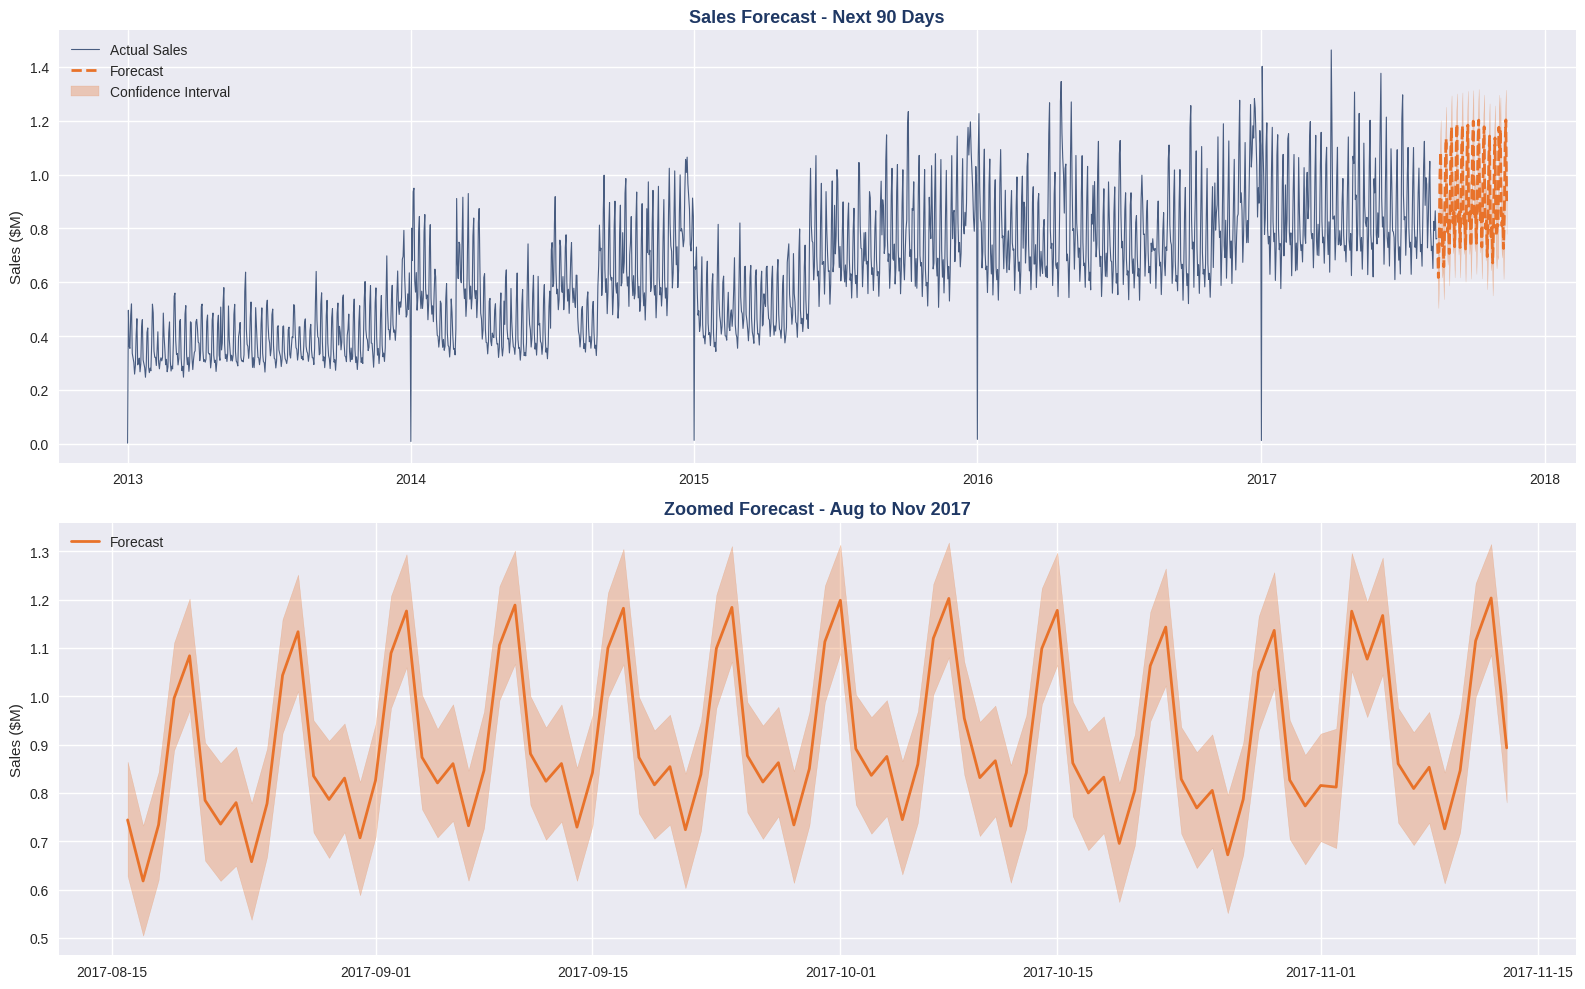


Forecasted avg daily sales (next 90 days) :
$903,043
Range : $785,877 → $1,020,348


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Chart 1 - Full forecast
axes[0].plot(prophet_data['ds'],
             prophet_data['y'] / 1e6,
             color='#1F3864', linewidth=0.8,
             label='Actual Sales', alpha=0.8)

future_only = forecast[forecast['ds'] >
                       prophet_data['ds'].max()]

axes[0].plot(future_only['ds'],
             future_only['yhat'] / 1e6,
             color='#E8722A', linewidth=2,
             label='Forecast', linestyle='--')

axes[0].fill_between(future_only['ds'],
                     future_only['yhat_lower'] / 1e6,
                     future_only['yhat_upper'] / 1e6,
                     alpha=0.3, color='#E8722A',
                     label='Confidence Interval')

axes[0].set_title('Sales Forecast - Next 90 Days',
                   fontsize=13, fontweight='bold',
                   color='#1F3864')
axes[0].set_ylabel('Sales ($M)')
axes[0].legend()

# Chart 2 - Forecast only zoomed
axes[1].plot(future_only['ds'],
             future_only['yhat'] / 1e6,
             color='#E8722A', linewidth=2,
             label='Forecast')
axes[1].fill_between(future_only['ds'],
                     future_only['yhat_lower'] / 1e6,
                     future_only['yhat_upper'] / 1e6,
                     alpha=0.3, color='#E8722A')
axes[1].set_title('Zoomed Forecast - Aug to Nov 2017',
                   fontsize=13, fontweight='bold',
                   color='#1F3864')
axes[1].set_ylabel('Sales ($M)')
axes[1].legend()

plt.tight_layout()
plt.savefig('forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nForecasted avg daily sales (next 90 days) :")
print(f"${future_only['yhat'].mean():,.0f}")
print(f"Range : ${future_only['yhat_lower'].mean():,.0f}"
      f" → ${future_only['yhat_upper'].mean():,.0f}")

### Step - Model Components Analysis

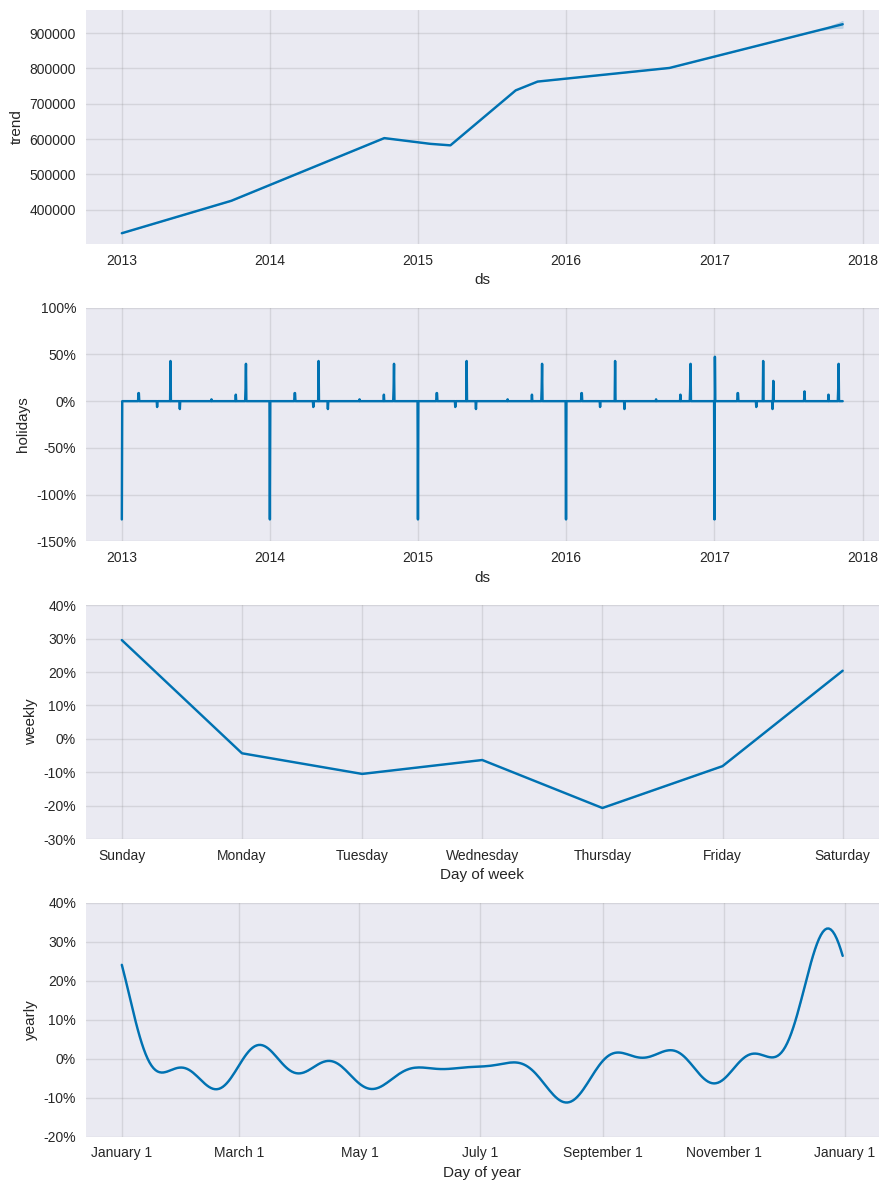

In [22]:
# Plot Prophet components
fig = model.plot_components(forecast)
plt.savefig('forecast_components.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Step 5 - Model Evaluation

MODEL EVALUATION
MAE  : $69,394
RMSE : $92,209
MAPE : 14.75%


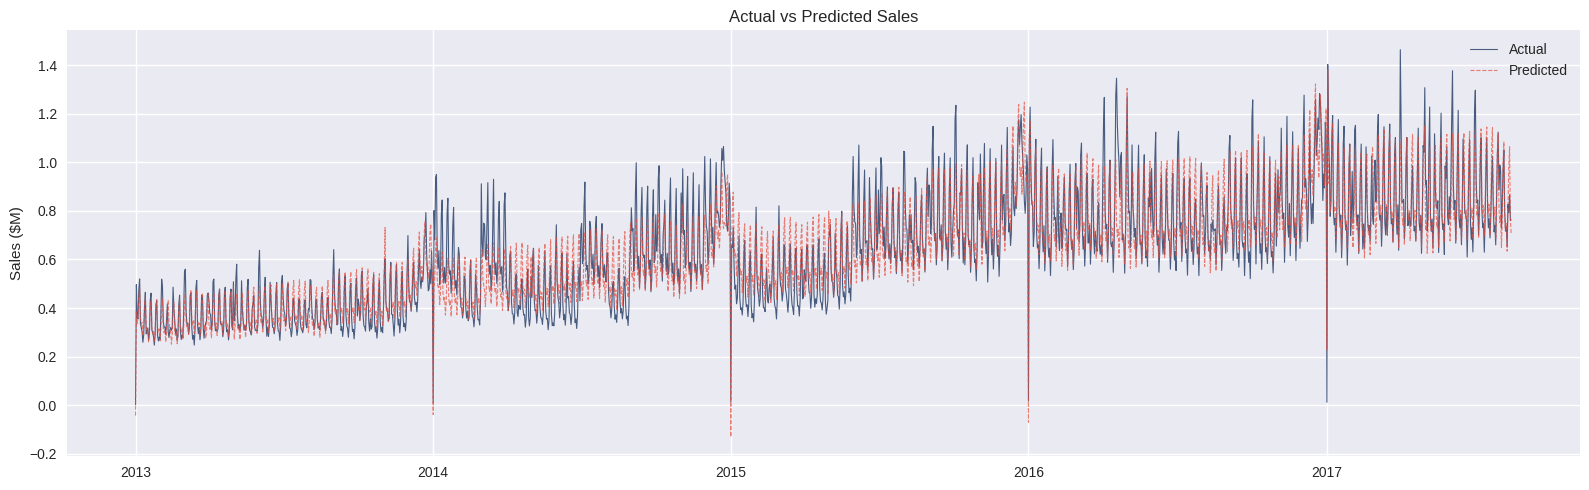

In [23]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Compare actual vs predicted on training data
actual = prophet_data['y'].values
predicted = forecast[forecast['ds'].isin(
    prophet_data['ds'])]['yhat'].values

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs(
    (actual - predicted) / actual)) * 100

print("=" * 45)
print("MODEL EVALUATION")
print("=" * 45)
print(f"MAE  : ${mae:,.0f}")
print(f"RMSE : ${rmse:,.0f}")
print(f"MAPE : {mape:.2f}%")
print("=" * 45)

# Visualization actual vs predicted
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(prophet_data['ds'],
        actual / 1e6,
        color='#1F3864', linewidth=0.8,
        label='Actual', alpha=0.8)
ax.plot(prophet_data['ds'],
        predicted / 1e6,
        color='#E74C3C', linewidth=0.8,
        label='Predicted', alpha=0.7,
        linestyle='--')
ax.set_title('Actual vs Predicted Sales')
ax.set_ylabel('Sales ($M)')
ax.legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 💡 Key Business Insights and Recommendations

In [39]:
print("=" * 55)
print("STORE SALES - BUSINESS INSIGHTS")
print("=" * 55)

print("\n📈 GROWTH TREND")
print("-" * 55)
print("Sales grew from $140M in 2013 to $289M")
print("in 2016 - more than doubling in three years.")
print("Average daily sales climbed from $385K")
print("to $791K over the same period.")
print("The business has strong structural momentum")
print("worth protecting and building on.")

print("\n🏪 STORE PERFORMANCE GAP")
print("-" * 55)
print("Type A stores generate $39M per store")
print("on average - 3.5x more than Type C stores")
print("at $11M. With 15 Type C stores in the")
print("network, closing even half that gap would")
print("represent a significant revenue opportunity.")
print("Understanding what Type A stores do")
print("differently is the right starting point.")

print("\n🛒 PRODUCT MIX CONCENTRATION")
print("-" * 55)
print("Grocery I alone accounts for $343M -")
print("more than Beverages and Produce combined.")
print("The top 5 families drive approximately")
print("78% of total revenue across all stores.")
print("The remaining 28 families generate 22%.")
print("A rationalization review of the bottom")
print("10 families could free up shelf space")
print("and margin for higher-performing categories.")

print("\n🎯 PROMOTIONS EFFECTIVENESS")
print("-" * 55)
print("Promotions correlate at 0.575 with sales.")
print("They work - but the effect is not uniform.")
print("Concentrating promotional budget on the")
print("top 5 families during peak months")
print("(December and year-end) would maximize")
print("return on promotional investment.")

print("\n⛽ OIL PRICE AS LEADING INDICATOR")
print("-" * 55)
print("Oil price correlates at -0.628 with sales.")
print("As Ecuador is an oil-dependent economy,")
print("a $10 drop in WTI historically precedes")
print("economic pressure on consumer spending.")
print("Setting a monitoring threshold at $60/barrel")
print("would give management 4 to 6 weeks of")
print("lead time to adjust inventory and pricing.")

print("\n📅 SEASONALITY AND STAFFING")
print("-" * 55)
print("Weekend sales average $1.1M vs $638K")
print("on weekdays - 72% higher consistently.")
print("National holidays reduce sales by 6%")
print("on average, suggesting reduced opening hours.")
print("Aligning staffing and inventory with these")
print("patterns is a direct and low-cost action.")

print("\n🔮 FORECAST RELIABILITY")
print("-" * 55)
print("Base Prophet model achieves 14.75% MAPE.")
print("Adding oil price and promotions as external")
print("regressors improved it to 14.06%.")
print("Forecasted daily sales for the next 90 days")
print("range between $725K and $1.2M with weekend")
print("peaks around $1.1M - a reliable baseline")
print("for inventory and resource planning.")
print("A store-level model would push MAPE")
print("below 10% and is the logical next step.")

print("\n" + "=" * 55)
print("THREE THINGS WORTH ACTING ON NOW")
print("=" * 55)
print("First : benchmark Type A stores against")
print("Type C to identify transferable practices.")
print("The 3.5x performance gap is too large")
print("to ignore and too structured to be random.")
print("")
print("Second : set up an oil price alert at")
print("$60/barrel. The -0.628 correlation gives")
print("management a macro early warning signal")
print("no internal data source can replicate.")
print("")
print("Third : use the forecast model to plan")
print("staffing and inventory around weekend peaks")
print("and seasonal patterns. The data is clear,")
print("the model is ready - execution is the gap.")
print("=" * 55)

STORE SALES - BUSINESS INSIGHTS

📈 GROWTH TREND
-------------------------------------------------------
Sales grew from $140M in 2013 to $289M
in 2016 - more than doubling in three years.
Average daily sales climbed from $385K
to $791K over the same period.
The business has strong structural momentum
worth protecting and building on.

🏪 STORE PERFORMANCE GAP
-------------------------------------------------------
Type A stores generate $39M per store
on average - 3.5x more than Type C stores
at $11M. With 15 Type C stores in the
network, closing even half that gap would
represent a significant revenue opportunity.
Understanding what Type A stores do
differently is the right starting point.

🛒 PRODUCT MIX CONCENTRATION
-------------------------------------------------------
Grocery I alone accounts for $343M -
more than Beverages and Produce combined.
The top 5 families drive approximately
78% of total revenue across all stores.
The remaining 28 families generate 22%.
A rationalization 

In [43]:
from google.colab import files

charts = [
    'sales_trend.png',
    'heatmap_seasonality.png',
    'family_sales.png',
    'family_evolution.png',
    'store_type_analysis.png',
    'oil_impact.png',
    'forecast.png',
    'actual_vs_predicted.png'
]

print("Downloading charts...")
for chart in charts:
    try:
        files.download(chart)
        print(f" ok {chart}")
    except FileNotFoundError:
        print(f" Not found : {chart}")

print("\nDone ! Download notebook manually :")
print("File → Download → Download .ipynb")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 ok sales_trend.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

 ok forecast.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 ok actual_vs_predicted.png

Done ! Download notebook manually :
File → Download → Download .ipynb
